<a href="https://colab.research.google.com/github/dimiryat/yfinance_example/blob/main/Investment_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*   初始化要用的模組以及產生資料
*   yfinance的使用方式隨時會變動,所以要注意

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

stock1_name = "VOO"
stock2_name = "TLT"
tickers = [stock1_name, stock2_name]
start_date = "2019-01-01"
end_date = "2026-01-01"

df = yf.download(tickers, start=start_date, end=end_date, auto_adjust=False, actions=True)

non_stock_pct=0.3
stock_pct=1-non_stock_pct
begin_money=100000.0 #初紿資金
stock_adjust_upper_threshold=0.85
stock_adjust_lower_threshold=0.55

df[('Stock_qty',stock2_name)]=0
df[('Stock_qty',stock1_name)]=0
df[('Cash_balance','')]=begin_money
df[('Current_value',stock2_name)]=df[('Stock_qty',stock2_name)]*df[('Close',stock2_name)]
df[('Current_value',stock1_name)]=df[('Stock_qty',stock1_name)]*df[('Close',stock1_name)]
df[('Stock_current_value','')]=df[('Current_value',stock2_name)]+df[('Current_value',stock1_name)]
df[('Hold_pct',stock2_name)]=0.0
df[('Hold_pct',stock1_name)]=0.0
df[('Total_value','')]=df[('Current_value',stock2_name)]+df[('Current_value',stock1_name)]+df[('Cash_balance','')]

#df.info()
#df.head(3)

stocks_adj_flag=False
Total_adj_flag=True

for i in range(len(df)):
  index = df.index[i] # Get the Timestamp for the current row
  row = df.loc[index] # Get the current row data as a Series

  # Determine the index of the previous day, if available
  prev_index = df.index[i-1] if i > 0 else None

  # Handle cash balance carry-over and dividends (for days after the first)
  if i > 0: # This block executes from the second day onwards
    # Carry over cash balance from previous day
    df.loc[index,('Cash_balance','')]=df.loc[prev_index,('Cash_balance','')]
    # Add dividends from previous day's holdings
    if row[('Dividends',stock2_name)]>0:
      df.loc[index,('Cash_balance','')]+=row[('Dividends',stock2_name)]*df.loc[prev_index,('Stock_qty',stock2_name)]
    if row[('Dividends',stock1_name)]>0:
      df.loc[index,('Cash_balance','')]+=row[('Dividends',stock1_name)]*df.loc[prev_index,('Stock_qty',stock1_name)]

  if Total_adj_flag: # This block executes only on the first day (i=0)
    #以開盤的價格決定要買的股數並計算剩下的現金
    df.loc[index,('Stock_qty',stock1_name)]=int((df.loc[index,('Total_value','')]*stock_pct)//row[('Open',stock1_name)])
    df.loc[index,('Stock_qty',stock2_name)]=int((df.loc[index,('Total_value','')]*non_stock_pct)//row[('Open',stock2_name)])
    df.loc[index,('Cash_balance','')]=df.loc[index,('Total_value','')]-df.loc[index,('Stock_qty',stock1_name)]*row[('Open',stock1_name)]-df.loc[index,('Stock_qty',stock2_name)]*row[('Open',stock2_name)]
    #計算收盤時的各項數值
    df.loc[index,('Current_value',stock2_name)]=df.loc[index,('Stock_qty',stock2_name)]*row[('Close',stock2_name)]
    df.loc[index,('Current_value',stock1_name)]=df.loc[index,('Stock_qty',stock1_name)]*row[('Close',stock1_name)]
    df.loc[index,('Stock_current_value','')]=df.loc[index,('Current_value',stock2_name)]+df.loc[index,('Current_value',stock1_name)]
    df.loc[index,('Hold_pct',stock1_name)]=df.loc[index,('Current_value',stock1_name)]/df.loc[index,('Stock_current_value','')] if df.loc[index,('Stock_current_value','')] != 0 else 0.0
    df.loc[index,('Hold_pct',stock2_name)]=df.loc[index,('Current_value',stock2_name)]/df.loc[index,('Stock_current_value','')] if df.loc[index,('Stock_current_value','')] != 0 else 0.0
    df.loc[index,('Total_value','')]=df.loc[index,('Stock_current_value','')]+df.loc[index,('Cash_balance','')]
    Total_adj_flag=False
    stocks_adj_flag=False

  elif stocks_adj_flag: # This block executes on subsequent days if rebalance is triggered
    #以前一日的股數和今日的開盤價來計算要買的新股數,及歸回cash balance的現金
    # Calculate value of previous day's stocks at current day's open price
    prev_stock_value_at_open = df.loc[prev_index,('Stock_qty',stock2_name)]*row[('Open',stock2_name)] + \
                  df.loc[prev_index,('Stock_qty',stock1_name)]*row[('Open',stock1_name)] + \
                  df.loc[index,('Cash_balance','')]
    # Adjust stock quantity
    df.loc[index,('Stock_qty',stock1_name)]=int((prev_stock_value_at_open*stock_pct)//row[('Open',stock1_name)])
    df.loc[index,('Stock_qty',stock2_name)]=int((prev_stock_value_at_open*non_stock_pct)//row[('Open',stock2_name)])
    # Adjust cash balance: add cash from selling, subtract cash for buying
    df.loc[index,('Cash_balance','')] = prev_stock_value_at_open - \
                      (df.loc[index,('Stock_qty',stock1_name)]*row[('Open',stock1_name)] + \
                      df.loc[index,('Stock_qty',stock2_name)]*row[('Open',stock2_name)])
    #計算收盤時的各項數值
    df.loc[index,('Current_value',stock2_name)]=df.loc[index,('Stock_qty',stock2_name)]*row[('Close',stock2_name)]
    df.loc[index,('Current_value',stock1_name)]=df.loc[index,('Stock_qty',stock1_name)]*row[('Close',stock1_name)]
    df.loc[index,('Stock_current_value','')]=df.loc[index,('Current_value',stock2_name)]+df.loc[index,('Current_value',stock1_name)]
    df.loc[index,('Hold_pct',stock1_name)]=df.loc[index,('Current_value',stock1_name)]/df.loc[index,('Stock_current_value','')] if df.loc[index,('Stock_current_value','')] != 0 else 0.0
    df.loc[index,('Hold_pct',stock2_name)]=df.loc[index,('Current_value',stock2_name)]/df.loc[index,('Stock_current_value','')] if df.loc[index,('Stock_current_value','')] != 0 else 0.0
    df.loc[index,('Total_value','')]=df.loc[index,('Stock_current_value','')]+df.loc[index,('Cash_balance','')]
    stocks_adj_flag=False

  else: # This block executes on subsequent days if no rebalance is triggered
    #不需要調整比例的狀況
    df.loc[index,('Stock_qty',stock1_name)]=df.loc[prev_index,('Stock_qty',stock1_name)]
    df.loc[index,('Stock_qty',stock2_name)]=df.loc[prev_index,('Stock_qty',stock2_name)]
    df.loc[index,('Current_value',stock1_name)]=df.loc[index,('Stock_qty',stock1_name)]*row[('Close',stock1_name)]
    df.loc[index,('Current_value',stock2_name)]=df.loc[index,('Stock_qty',stock2_name)]*row[('Close',stock2_name)]
    df.loc[index,('Stock_current_value','')]=df.loc[index,('Current_value',stock2_name)]+df.loc[index,('Current_value',stock1_name)]
    df.loc[index,('Hold_pct',stock1_name)]=df.loc[index,('Current_value',stock1_name)]/df.loc[index,('Stock_current_value','')] if df.loc[index,('Stock_current_value','')] != 0 else 0.0
    df.loc[index,('Hold_pct',stock2_name)]=df.loc[index,('Current_value',stock2_name)]/df.loc[index,('Stock_current_value','')] if df.loc[index,('Stock_current_value','')] != 0 else 0.0
    df.loc[index,('Total_value','')]=df.loc[index,('Stock_current_value','')]+df.loc[index,('Cash_balance','')]
    if df.loc[index,('Hold_pct',stock1_name)]>=stock_adjust_upper_threshold:
      stocks_adj_flag=True
    if df.loc[index,('Hold_pct',stock1_name)]<=stock_adjust_lower_threshold:
      stocks_adj_flag=True
#df.to_csv('result.csv')

[*********************100%***********************]  2 of 2 completed


In [ ]:
df.tail(1)

Price       Adj Close             Capital Gains           Close              \
Ticker            TLT         VOO           TLT  VOO        TLT         VOO   
Date                                                                          
2025-12-31  86.827888  627.130005           0.0  0.0  87.160004  627.130005   

Price      Dividends            High              ...   Volume Stock_qty       \
Ticker           TLT  VOO        TLT         VOO  ...      VOO       TLT  VOO   
Date                                              ...                           
2025-12-31       0.0  0.0  87.910004  632.140015  ...  5556800       533  275   

Price      Cash_balance Current_value                Stock_current_value  \
Ticker                            TLT            VOO                       
Date                                                                       
2025-12-31  8931.887606  46456.281952  172460.751343       218917.033295   

Price      Hold_pct             Total_value  
Ticker          TLT      VOO                 
Date                                         
2025-12-31  0.21221  0.78779  227848.920901  

[1 rows x 27 columns]

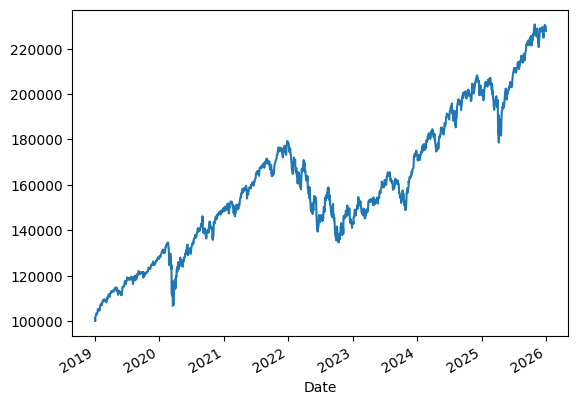

In [ ]:
df[('Total_value','')].plot()
plt.show()

In [ ]:
fig = make_subplots(specs=[[{"secondary_y": False}]])
# 3. 加入第一條線 (股價) -> 對應主軸 (secondary_y=False)
fig.add_trace(
    go.Scatter(x=df.index, y=df[('Total_value','')], name="Total value"),
    secondary_y=False,
)
# 5. 設定軸的標籤與標題
fig.update_layout(
    title_text="Invest result",
    width=1000, height=600
)
# 設定 Y 軸標題
fig.update_yaxes(title_text="Total Value", secondary_y=False)
fig.show()

In [ ]:
fig = make_subplots(specs=[[{"secondary_y": False}]])
# 3. 加入第一條線 (股價) -> 對應主軸 (secondary_y=False)
fig.add_trace(
    go.Scatter(x=df.index, y=df[('Close',stock1_name)], name=stock1_name+" close price"),
    secondary_y=False,
)
# 5. 設定軸的標籤與標題
fig.update_layout(
    title_text=stock1_name+" close price",
    width=1000, height=600
)
# 設定 Y 軸標題
fig.update_yaxes(title_text=stock1_name+" close price", secondary_y=False)
fig.show()

In [ ]:
fig = make_subplots(specs=[[{"secondary_y": False}]])
# 3. 加入第一條線 (股價) -> 對應主軸 (secondary_y=False)
fig.add_trace(
    go.Scatter(x=df.index, y=df[('Close',stock2_name)], name=stock2_name+" close price"),
    secondary_y=False,
)
# 5. 設定軸的標籤與標題
fig.update_layout(
    title_text=stock2_name+" close price",
    width=1000, height=600
)
# 設定 Y 軸標題
fig.update_yaxes(title_text=stock2_name+" close price", secondary_y=False)
fig.show()